# Coördinaten van klinische onderzoekscentra projecteren voor kaarten met PROC GPROJECT

## Samenvatting

Een team klinische operaties moet de geografische voetafdruk van een
multi-center fase III-onderzoek op een platte kaart weergeven. Dit
notebook genereert synthetische lengte-/breedtegraadcoördinaten voor
onderzoekscentra die geclusterd zijn rond vijf regionale hubs in de VS, en
gebruikt vervolgens **PROC GPROJECT** om de sferische coördinaten om te
zetten naar Cartesische X/Y-waarden met drie projectiemethoden (Albers
equal-area, Lambert conform met aangepaste standaardparallellen en
regionale bijsnijding, en gnomonisch gecentreerd op het vasteland van de
VS), wat illustreert hoe de keuze van projectie en bijsnijding een
centrumkaart beïnvloeden.

## Gegevensbronnen

| Dataset | Rijen | Kernvariabelen | Beschrijving |
|---------|------|---------------|-------------|
| `trial_sites` | 60 (5 hubs x 12 centra) | `site_id` (ID, $8), `region` ($9), `x` (lengtegraad, graden, oost-positief), `y` (breedtegraad, graden), `enroll` (ingeschreven deelnemers), `segment` (kaartsegment-id) | Synthetische locaties van fase III-onderzoekscentra verspreid rond vijf regionale hubs in de VS (West, Midwesten, Noordoosten, Zuiden, Zuidoosten) met `rand('normal')`-jitter en `rand('poisson')`-inschrijvingsaantallen |

# Coördinaten van klinische onderzoekscentra projecteren met PROC GPROJECT

Wanneer een sponsor een geografisch verspreid fase III-onderzoek uitvoert,
wil de groep klinische operaties vaak één kaart die elk onderzoekscentrum
toont, met grootte of kleur naar inschrijving. Locaties van centra komen
binnen als **lengtegraad-/breedtegraadparen**, maar een platte kaart heeft
**planaire X/Y-coördinaten** nodig. `PROC GPROJECT` voert die sferisch-
naar-Cartesische omzetting uit, met toepassing van een cartografische
projectie zodat afstanden en oppervlakken zinvol worden weergegeven.

In dit notebook doen we het volgende:

1. Genereer synthetische coördinaten van centra geclusterd rond vijf
   regionale hubs in de VS.
2. Pas de standaard **Albers equal-area**-projectie toe.
3. Pas een **Lambert conforme** projectie toe met aangepaste
   standaardparallellen en bijsnijding tot de aaneengesloten VS.
4. Pas een **gnomonische** projectie toe, gecentreerd op het geografische
   midden van het land, met behoud van de originele coördinaten via
   `ASIS`.

Alles is zelfstandig: geen externe bestanden, geen netwerk.

## Stap 1 — Genereer synthetische coördinaten van onderzoekscentra

We seeden de RNG met `call streaminit` voor reproduceerbaarheid, en
plaatsen vervolgens 12 centra rond elk van vijf regionale hubsteden.
Lengtegraden worden oost-positief opgeslagen in graden (negatief voor het
westelijk halfrond) en breedtegraden in graden. Elke rij draagt ook een
inschrijvingsaantal en een `segment`-variabele (GPROJECT behoudt
niet-coördinaatkolommen door de projectie heen).

In [1]:
GEGEVENS trial_sites;
    CALL streaminit(20260531);
    LENGTE site_id $8 region $11;
    /* Vijf regionale hubcentra in de VS: lengtegraad (oost+), breedtegraad */
    REEKS clon[5]  _temporary_ (-122.3 -87.6 -71.1 -95.4 -80.2);
    REEKS clat[5]  _temporary_ (  37.8  41.9  42.4  29.8  25.8);

    DOE hub = 1 TOT 5;
        ALS hub = 1 DAN region = 'West';
        ANDERS ALS hub = 2 DAN region = 'Midwesten';
        ANDERS ALS hub = 3 DAN region = 'Noordoosten';
        ANDERS ALS hub = 4 DAN region = 'Zuiden';
        ANDERS region = 'Zuidoosten';
        DOE s = 1 TOT 12;
            site_id = cats('S', SCHRIJVEN(hub, z1.), SCHRIJVEN(s, z2.));
            x       = clon[hub] + rand('normal', 0, 1.4);   /* lengtegraad, graden */
            y       = clat[hub] + rand('normal', 0, 1.0);   /* breedtegraad, graden */
            enroll  = round(rand('poisson', 60));           /* ingeschreven deelnemers */
            segment = 1;
            UITVOER;
        EINDE;
    EINDE;
    VERWIJDEREN hub s;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=trial_sites(obs=10) label;
    label site_id="Centrum-ID" region="Regio" x="Lengtegraad (X)" y="Breedtegraad (Y)"
          enroll="Ingeschreven deelnemers" segment="Segment";
    TITEL "Steekproef van synthetische klinische onderzoekscentra (niet-geprojecteerde lengte-/breedtegraad)";
UITVOEREN;

           Steekproef van synthetische klinische onderzoekscentra (niet-geprojecteerde lengte-/breedtegraad)            

  Obs  Centrum-ID  Regio  Lengtegraad (X)  Breedtegraad (Y)  Ingeschreven deelnemers  Segment
    1  S101        West   -121.6437232216     37.7677668495                       65        1
    2  S102        West   -120.7384024716     37.5083287903                       61        1
    3  S103        West   -121.5133780284     37.8633933883                       72        1
    4  S104        West   -121.2086817368     38.7723343392                       68        1
    5  S105        West   -121.0499572297      37.175813806                       54        1
    6  S106        West   -124.0531899967      35.778231667                       72        1
    7  S107        West   -120.9370181032     39.0576714397                       64        1
    8  S108        West   -126.8495029747     36.6474680375                       55        1
    9  S109        West    -123.


NOTE: DATA trial_sites


NOTE: Wrote trial_sites (60 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=trial_sites

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Stap 2 — Standaard Albers equal-area-projectie

De **Albers** equal-area kegelprojectie is de standaard van GPROJECT en
een zinvolle keuze voor een kaart op landschaal waarbij het behoud van
*relatieve oppervlakte* belangrijk is (bijvoorbeeld bij het vergelijken
van de omvang van regionale verzorgingsgebieden).

Omdat onze coördinaten zijn opgeslagen in **graden** met **oost-positieve
lengtegraad**, geven we de opties `DEGREE` en `EASTLONG` op. Het
`ID`-statement noemt de variabele die elke eenheid uniek identificeert; de
geprojecteerde planaire coördinaten worden teruggeschreven in `x` en `y`
in de `OUT=`-dataset.

In [2]:
PROCEDURE GPROJECT GEGEVENS=trial_sites out=sites_albers
        DEGREE eastlong;
    id site_id;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=sites_albers(obs=10) label;
    label site_id="Centrum-ID" region="Regio" x="Geprojecteerde X" y="Geprojecteerde Y"
          enroll="Ingeschreven deelnemers" segment="Segment";
    TITEL "Onderzoekscentra na Albers equal-area-projectie (planaire X/Y)";
UITVOEREN;

           Steekproef van synthetische klinische onderzoekscentra (niet-geprojecteerde lengte-/breedtegraad)            

                             Onderzoekscentra na Albers equal-area-projectie (planaire X/Y)                             

  Obs  Centrum-ID  Regio  Geprojecteerde X  Geprojecteerde Y  Ingeschreven deelnemers  Segment
    1  S101        West       -0.346124731      0.0516986079                       65        1
    2  S102        West      -0.3353644139      0.0440400181                       61        1
    3  S103        West      -0.3439609675      0.0528501365                       72        1
    4  S104        West      -0.3357513354       0.067213083                       68        1
    5  S105        West      -0.3410170723      0.0394882801                       54        1
    6  S106        West      -0.3879364507      0.0273340733                       72        1
    7  S107        West      -0.3309127579      0.0711146305                       64      


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=ALBERS)
NOTE: PROC PRINT data=sites_albers

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Stap 3 — Lambert conforme projectie met aangepaste parallellen en bijsnijding

De **Lambert conforme** kegelprojectie behoudt *vorm en lokale hoeken*,
wat de voorkeur heeft wanneer de kaart wordt gebruikt voor navigatie of
voor het overlayen van richtinggevende kenmerken. Voor de aaneengesloten
VS zijn standaardparallellen rond 33 graden N en 45 graden N gebruikelijk,
dus stellen we ze expliciet in met `PARALLEL1=` en `PARALLEL2=`.

We beperken de kaart ook tot het venster van de aaneengesloten VS met de
bijsnijdopties `LATMIN=`, `LATMAX=`, `LONGMIN=` en `LONGMAX=`. Elk centrum
dat buiten deze lengte-/breedtegraadbox valt, wordt verwijderd vóór
projectie, dus het aantal outputwaarnemingen kan lager zijn dan de
invoer.

In [3]:
PROCEDURE GPROJECT GEGEVENS=trial_sites out=sites_lambert
        project=lambert DEGREE eastlong
        parallel1=33 parallel2=45
        latmin=24 latmax=50 longmin=-125 longmax=-66;
    id site_id;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=sites_lambert(obs=10) label;
    label site_id="Centrum-ID" region="Regio" x="Geprojecteerde X" y="Geprojecteerde Y"
          enroll="Ingeschreven deelnemers" segment="Segment";
    TITEL "Onderzoekscentra na Lambert-conforme projectie (bijgesneden tot aaneengesloten VS)";
UITVOEREN;

                             Onderzoekscentra na Albers equal-area-projectie (planaire X/Y)                             

                   Onderzoekscentra na Lambert-conforme projectie (bijgesneden tot aaneengesloten VS)                   

  Obs  Centrum-ID  Regio  Geprojecteerde X  Geprojecteerde Y  Ingeschreven deelnemers  Segment
    1  S101        West      -0.3473024124      0.0279382533                       65        1
    2  S102        West      -0.3365626234      0.0201991247                       61        1
    3  S103        West      -0.3451238364      0.0290365995                       72        1
    4  S104        West      -0.3367881094      0.0430616123                       68        1
    5  S105        West      -0.3422656751      0.0158037156                       54        1
    6  S106        West      -0.3894389642      0.0046370991                       72        1
    7  S107        West      -0.3319086764      0.0468276119                       64      


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 58 observations projected (project=LAMBERT)
NOTE: PROC PRINT data=sites_lambert

NOTE: PROC PRINT completed: 10 observations printed, 6 variables


## Stap 4 — Gnomonische projectie gecentreerd op het land, met behoud van originelen

De **gnomonische** azimutale projectie geeft elke grootcirkel weer als een
rechte lijn, wat nuttig is wanneer u wilt redeneren over de kortste route
tussen centra (bijvoorbeeld bij het plannen van de reisroute van een
monitor langs de centra). Vervorming neemt toe met de afstand tot de
projectiepool, dus centreren we de pool op het geografische midden van het
vasteland van de VS met `POLELAT=39` en `POLELONG=-98`.

De optie `ASIS` vertelt GPROJECT om de originele niet-geprojecteerde
coördinaten naast de geprojecteerde waarden te behouden, zodat de
outputdataset zowel de planaire `X`/`Y` als de brondata `LONG`/`LAT`
draagt — handig om inschrijvingsmetrieken terug te koppelen naar beide
coördinaatruimtes.

Het `PARMENTRY`-statement wordt getoond als alternatieve manier om
projectieparameters op te geven als key=value-overrides.

In [4]:
PROCEDURE GPROJECT GEGEVENS=trial_sites out=sites_gnomon
        project=gnomon DEGREE eastlong asis
        polelat=39 polelong=-98;
    id site_id;
    parmentry polelat=39 polelong=-98;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=sites_gnomon(obs=10) label;
    label site_id="Centrum-ID" region="Regio" x="Geprojecteerde X" y="Geprojecteerde Y"
          enroll="Ingeschreven deelnemers" segment="Segment";
    TITEL "Onderzoekscentra na gnomonische projectie (ASIS behoudt originele LONG/LAT)";
UITVOEREN;

                   Onderzoekscentra na Lambert-conforme projectie (bijgesneden tot aaneengesloten VS)                   

                      Onderzoekscentra na gnomonische projectie (ASIS behoudt originele LONG/LAT)                       

  Obs  Centrum-ID  Regio  Geprojecteerde X  Geprojecteerde Y  Ingeschreven deelnemers  Segment             LONG            LAT
    1  S101        West      -0.3343477981      0.0213614461                       65        1  -121.6437232216  37.7677668495
    2  S102        West      -0.3221611694      0.0134152735                       61        1  -120.7384024716  37.5083287903
    3  S103        West      -0.3319480803      0.0225717184                       72        1  -121.5133780284  37.8633933883
    4  S104        West      -0.3230855797      0.0375741352                       68        1  -121.2086817368  38.7723343392
    5  S105        West      -0.3283677206      0.0086308769                       54        1  -121.0499572297   37.1758


NOTE: PROC GPROJECT data=trial_sites

NOTE: PROC GPROJECT: 60 observations projected (project=GNOMON)
NOTE: PROC PRINT data=sites_gnomon

NOTE: PROC PRINT completed: 10 observations printed, 8 variables


## Stap 5 — Render de geprojecteerde centrumkaart

Het hele punt van projecteren is om de kaart te tekenen. We voeren de
Albers `OUT=`-dataset rechtstreeks in **PROC SGPLOT** in, waarbij we de
planaire `X`/`Y` plotten en elke marker kleuren op `region`. Omdat de
projectie de relatieve geografie behield, landen de vijf hubclusters in
hun verwachte hoeken van de plot — West links, Noordoosten rechtsboven,
Zuiden en Zuidoosten onderaan — wat klinische operaties de
oppervlaktegetrouwe voetafdruk geeft die in de samenvatting werd
beschreven.

                      Onderzoekscentra na gnomonische projectie (ASIS behoudt originele LONG/LAT)                       




NOTE: PROC SGPLOT data=sites_albers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


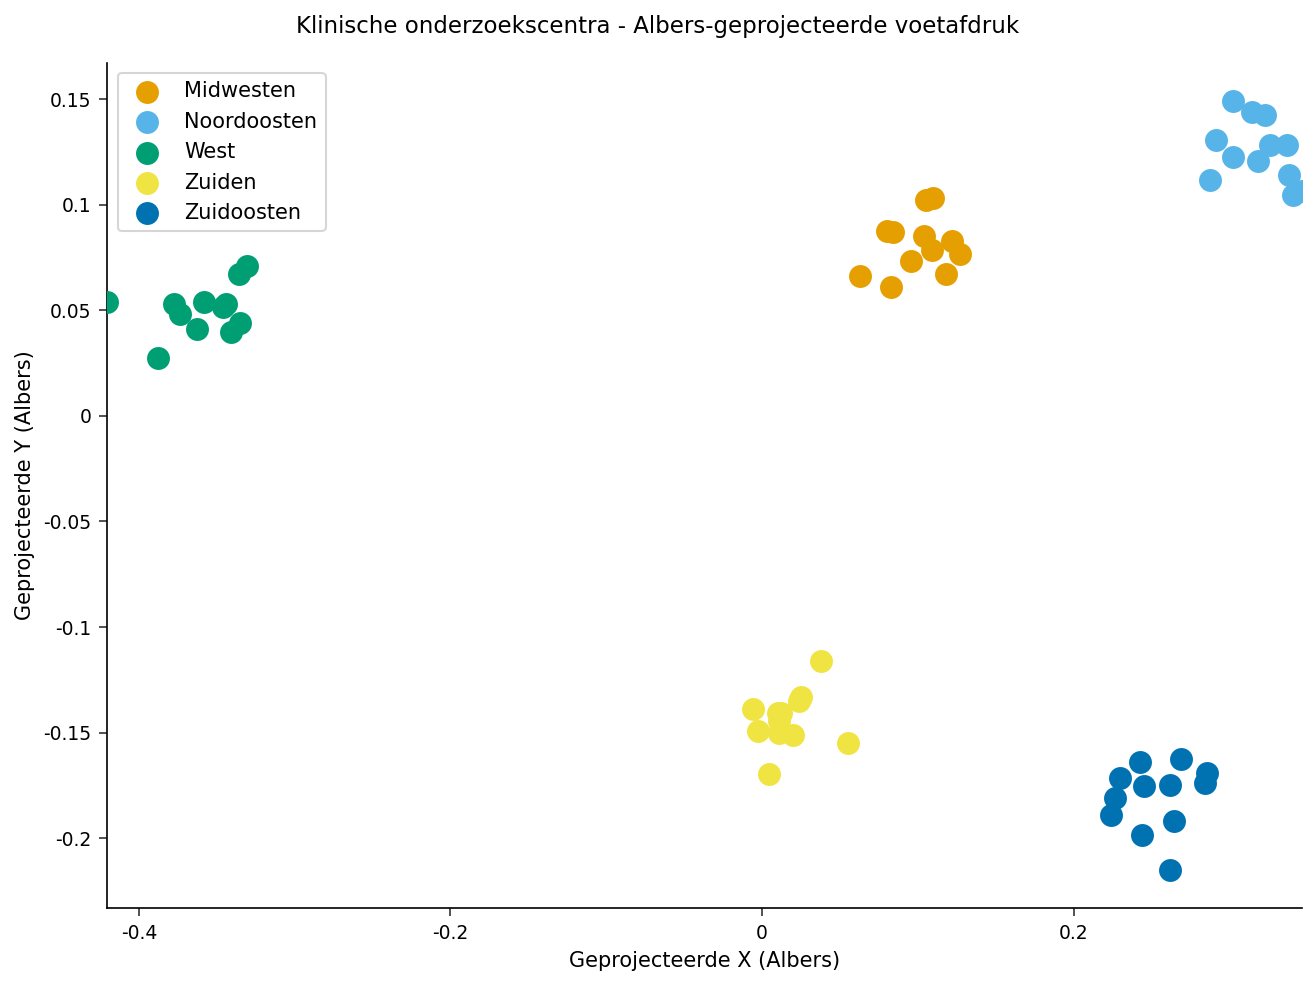

In [5]:
PROCEDURE SGPLOT GEGEVENS=sites_albers;
    SCATTER x=x y=y / GROUP=region
            MARKERATTRS=(SYMBOL=circlefilled size=10);
    XAXIS label="Geprojecteerde X (Albers)";
    YAXIS label="Geprojecteerde Y (Albers)";
    TITEL "Klinische onderzoekscentra - Albers-geprojecteerde voetafdruk";
UITVOEREN;

## Interpretatie van de resultaten

- **Albers (stap 2)** zette alle 60 centra om naar planaire coördinaten
  met behoud van relatieve oppervlakte — de clusters West, Midwesten,
  Noordoosten, Zuiden en Zuidoosten behouden hun proportionele ruimtelijke
  voetafdruk, wat de juiste basis is voor een oppervlaktegetrouwe
  inschrijvings-heatmap.
- **Lambert met bijsnijding (stap 3)** behield lokale vorm en liet, door
  toepassing van het venster `LATMIN`/`LATMAX`/`LONGMIN`/`LONGMAX`, de
  synthetische centra vallen die buiten de aaneengesloten VS lagen — hier
  daalde het aantal van 60 naar 58, zodat de twee coördinaten buiten het
  raster die de kaart anders zouden uitrekken, vóór projectie werden
  verwijderd.
- **Gnomonisch met `ASIS` (stap 4)** centreerde de projectie op het
  binnenland van het land en produceerde, dankzij `ASIS`, een dataset die
  zowel de geprojecteerde `X`/`Y` als de originele `LONG`/`LAT` draagt.
  Grootcirkels verschijnen als rechte lijnen, dus rechte-lijnafstanden op
  deze kaart benaderen echte kortste paden tussen centra.
- **De gerenderde voetafdruk (stap 5)** bevestigt dat de projectie werkte:
  het plotten van de Albers `X`/`Y` per regio plaatst de vijf hubclusters
  in hun verwachte hoeken van het vlak, de oppervlaktegetrouwe
  centrumkaart die in de samenvatting werd beloofd.

**Conclusie voor klinische operaties:** de projectie is niet louter
cosmetisch. Kies **Albers** voor oppervlaktegetrouwe
inschrijvingsdichtheid, **Lambert** voor vormgetrouwe overlays met
regionale bijsnijding, en **gnomonisch** wanneer de reisafstand tussen
centra de analyse stuurt. Zoals stap 5 laat zien, gaat de geprojecteerde
`OUT=`-dataset direct in PROC SGPLOT (of PROC GMAP) om de uiteindelijke
centrumkaart te renderen.